In [1]:
from __future__ import annotations
import operator
import os
import re
from datetime import date, datetime, timedelta
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11400\746373007.py:15: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
#schemas
class Task(BaseModel):
  id: int
  title: str

  goal: str = Field(
    ...,
    description="One sentence describing what the reader should be able to do/understand after this section.",
  )
  bullets: List[str] = Field(
    ...,
    min_length=3,
    max_length=6,
    description="3–6 concrete, non-overlapping subpoints to cover in this section.",
  )
  target_words: int = Field(
    ...,
    description="Target word count for this section (120–550)."
  )
  tags: List[str] = Field(default_factory=list)
  requires_research: bool = False
  requires_citation: bool = False
  requires_code: bool = False

class Plan(BaseModel):
  blog_title: str
  audience: str
  tone: str

  blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
  constraints: List[str] = Field(default_factory=list)
  tasks: List[Task]

class EvidenceItem(BaseModel):
  title: str
  url: str
  published_at: Optional[str] = None
  snippet: Optional[str] = None
  source: Optional[str] = None

class RouterDecision(BaseModel):
  needs_research: bool
  mode: Literal["closed_book", "hybrid", "open_book"]
  reason: str
  queries: List[str] = Field(default_factory=list)
  max_results_per_query: int = Field(5, description="How many results to fetch per query (3–8).")

class EvidencePack(BaseModel):
  evidence: List[EvidenceItem] = Field(default_factory=list) 

class ImageSpec(BaseModel):
  placeholder: str = Field(..., description="e.g. [[IMAGE_1]]")
  filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
  alt: str
  caption: str
  prompt: str = Field(..., description="Natural-language prompt for an image model (fallback backend).")
  mermaid: Optional[str] = Field(
    None,
    description=(
      "Preferred: a complete, valid Mermaid diagram (flowchart/sequenceDiagram/classDiagram/etc.) "
      "that draws this image. Short node labels, no HTML, no markdown fences."
    ),
  )

class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)


In [3]:
class State(TypedDict):
  topic: str
  mode: str
  needs_research: bool
  queries: List[str]
  evidence: List[EvidenceItem]
  plan: Optional[Plan]

  as_of:str
  recency_days: int

  sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)

  merged_md: str
  md_with_placeholders: str
  image_specs: List[dict]

  final: str

In [4]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(
    model=os.environ["OPENROUTER_MODEL"],
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    temperature=0.3,
)

# The free OpenRouter endpoints intermittently answer with HTTP 200 + an error body
# (finish_reason='error', empty content). The OpenAI SDK turns that into a TypeError
# and LangChain's structured-output parser into a ValueError. Both are transient, so retry.
RETRY = dict(
    retry_if_exception_type=(TypeError, ValueError),
    stop_after_attempt=6,
    wait_exponential_jitter=True,
)

# Plain-text LLM with retries (used by the worker).
llm_retry = llm.with_retry(**RETRY)


def structured(schema):
    """Structured-output LLM with retries.

    langchain_openai defaults to method="json_schema" (OpenAI's native
    response_format), which most OpenRouter models don't support and which
    produced the "does not have a 'parsed' field" error. Tool/function calling
    is far more widely supported.
    """
    return llm.with_structured_output(schema, method="function_calling").with_retry(**RETRY)

In [5]:
#router
ROUTER_SYSTEM = """
You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- For open_book weekly roundup, include queries that reflect the last 7 days constraint.
"""

def router_node(state: State) -> dict:
  topic= state["topic"]
  decider = structured(RouterDecision)
  decision = decider.invoke(
    [
      SystemMessage(content=ROUTER_SYSTEM),
      HumanMessage(content=f"Topic: {topic}\nAs-of date: {state['as_of']}"),
    ]
  )

  if decision.mode == "open_book":
    recency_days = 7
  elif decision.mode == "hybrid":
    recency_days = 45
  else:
    recency_days = 3650
  return {
    "needs_research": decision.needs_research,
    "mode": decision.mode,
    "queries": decision.queries,
    "recency_days": recency_days,
  }      
def route_next(state: State) ->str:
  return "research" if state["needs_research"] else "orchestrator"

In [6]:
#reserach
def _tavily_search(query: str, max_results: int =5) -> List[dict]:
  """
    Uses TavilySearchResults if installed and TAVILY_API_KEY is set.
    Returns list of dict with common fields. Note: published date is often missing.
    """
  tool = TavilySearchResults(max_results=max_results)
  results = tool.invoke({"query": query})

  normalized: List[dict] = []
  for r in results or []:
    normalized.append(
      {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
      }
    )
  return normalized
def _iso_to_date(s: Optional[str]) -> Optional[date]:
  if not s:
    return None
  try:
    return date.fromisoformat(s[:10])
  except Exception:
    return None


RESEARCH_SYSTEM = """
You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- Extract/normalize published_at as ISO (YYYY-MM-DD) if you can infer it from title/snippet.
  If you can't infer a date reliably, set published_at=null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""    

def research_node(state: State) ->dict:
  queries = (state.get("queries", []) or [])[:10]
  max_results = 6
  raw_results: List[dict] = []
  for q in queries:
    raw_results.extend(_tavily_search(q, max_results=max_results))

  if not raw_results:
    return {"evidence": []}

  extractor = structured(EvidencePack)
  pack= extractor.invoke(
    [
      SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(
                content=(
                    f"As-of date: {state['as_of']}\n"
                    f"Recency days: {state['recency_days']}\n\n"
                    f"Raw results:\n{raw_results}"
                )
            ),
    ]
  ) 
  # Deduplicate by URL
  dedup = {}
  for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
  evidence = list(dedup.values())

    # HARD RECENCY FILTER for open_book weekly roundup:
    # keep only items with a parseable ISO date and within the window.
  mode = state.get("mode", "closed_book")
  if mode == "open_book":
        as_of = date.fromisoformat(state["as_of"])
        cutoff = as_of - timedelta(days=int(state["recency_days"]))
        fresh: List[EvidenceItem] = []
        for e in evidence:
            d = _iso_to_date(e.published_at)
            if d and d >= cutoff:
                fresh.append(e)
        evidence = fresh

  return {"evidence": evidence}  

In [7]:
#orchestrator
ORCH_SYSTEM = """
You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Flexibility:
- Do NOT use a fixed taxonomy unless it naturally fits.
- You may tag tasks (tags field), but tags are flexible.

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citation=True.
- Mode open_book (weekly news roundup):
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections (no scraping/RSS/how to fetch news) unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient fresh sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""
def orchestrator_node(state: State) -> dict:
  planner = structured(Plan)
  evidence = state.get("evidence", [])
  mode = state.get("mode", "closed_book")

  forced_kind = "news_roundup" if mode == "open_book" else None
  plan = planner.invoke(
    [
      SystemMessage(content=ORCH_SYSTEM),
      HumanMessage(
        content=(
          f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}\n\n"
                    f"Instruction: If mode=open_book, your plan must NOT drift into a tutorial."
        )
      ),
    ]
  )

  if forced_kind:
    plan.blog_kind = "news_roundup"

  return {"plan": plan}

def fanout(state:State):
  assert state["plan"] is not None
  return [
    Send(
      "worker",
      {
        "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "as_of": state["as_of"],
                "recency_days": state["recency_days"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
      },
    )
    for task in state["plan"].tasks
  ]  

In [8]:
#worker section
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard (prevents mid-blog topic drift):
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book (weekly news):
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citation == true (hybrid sections):
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning (concepts, intuition) is OK without citations unless requires_citation is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented."""

def worker_node(payload: dict) -> dict:
  task = Task(**payload["task"])
  plan = Plan(**payload["plan"])
  evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
  topic = payload["topic"]
  mode = payload.get("mode", "closed_book")
  as_of = payload.get("as_of")
  recency_days = payload.get("recency_days")
  bullets_text = "\n- " + "\n- ".join(task.bullets)

  evidence_text = ""
  if evidence:
    evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

  section_md = llm_retry.invoke(
    [
      SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {as_of} (recency_days={recency_days})\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citation: {task.requires_citation}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
    ]
  ).content.strip()

  return {"sections": [(task.id, section_md)]}

In [ ]:
import urllib.error
import urllib.request

# ============================================================
# 8) ReducerWithImages (subgraph)
#    merge_content -> decide_images -> generate_and_place_images
# ============================================================

# Image backends, tried in this order. "kroki" renders the LLM's Mermaid
# diagram (free, no key, exact labels). "gemini" uses gemini-2.5-flash-image
# (needs billing enabled on the Google AI Studio project).
IMAGE_BACKENDS = os.environ.get("IMAGE_BACKENDS", "kroki,gemini").split(",")


def slugify(title: str) -> str:
    """Filesystem-safe filename stem. On Windows a ':' in a filename silently
    writes into an NTFS alternate data stream, so strip everything unsafe."""
    s = re.sub(r"[^\w\s-]", "", title.lower())
    s = re.sub(r"[\s_-]+", "_", s).strip("_")
    return s or "blog"


def merge_content(state: State) -> dict:
    plan = state["plan"]
    if plan is None:
        raise ValueError("merge_content called without plan.")
    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md": merged_md}


DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]] on their own line
  at the position in the markdown where the image belongs.
- md_with_placeholders must be the FULL input markdown, unchanged except for the inserted placeholders.
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
- filename must be a simple lowercase name ending in .png (e.g. qkv_flow.png).
- For every image, ALSO provide `mermaid`: a complete valid Mermaid diagram that draws it
  (flowchart LR/TD, sequenceDiagram, etc.). Keep node labels short; quote labels that contain
  special characters, e.g. A["softmax(QK^T / sqrt(d_k))"]. No markdown fences.
Return strictly GlobalImagePlan.
"""


def decide_images(state: State) -> dict:
    planner = structured(GlobalImagePlan)
    merged_md = state["merged_md"]
    plan = state["plan"]
    assert plan is not None

    image_plan = planner.invoke(
        [
            SystemMessage(content=DECIDE_IMAGES_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Topic: {state['topic']}\n\n"
                    "Insert placeholders + propose image prompts.\n\n"
                    f"{merged_md}"
                )
            ),
        ]
    )

    md = image_plan.md_with_placeholders or merged_md
    images = list(image_plan.images)
    # Guard against the model truncating/rewriting the blog: if the returned
    # markdown lost more than 20% of the content, keep the original and
    # append the placeholders at the end instead.
    if len(md) < 0.8 * len(merged_md):
        md = merged_md
        for img in images:
            md += f"\n\n{img.placeholder}\n"
    else:
        images = [img for img in images if img.placeholder in md]

    return {
        "md_with_placeholders": md,
        "image_specs": [img.model_dump() for img in images],
    }


class MermaidFix(BaseModel):
    mermaid: str = Field(..., description="Corrected, complete Mermaid diagram source. No fences.")


MERMAID_FIX_SYSTEM = """You fix Mermaid diagram syntax errors.
Given a Mermaid source and the parser error, return a corrected diagram that keeps the same meaning.
Common fixes: wrap any label containing ( ) [ ] { } | ^ / , : or quotes in double quotes, e.g. A["softmax(QK^T)"];
use only ASCII; one edge per line; no markdown fences; no HTML."""


def _kroki_post(src: str) -> bytes:
    req = urllib.request.Request(
        "https://kroki.io/mermaid/png",
        data=src.encode("utf-8"),
        headers={"Content-Type": "text/plain", "User-Agent": "Mozilla/5.0"},
    )
    try:
        with urllib.request.urlopen(req, timeout=60) as r:
            data = r.read()
    except urllib.error.HTTPError as e:
        # Kroki's 400 body carries the Mermaid parse error - keep it for the repair step.
        raise RuntimeError(e.read().decode("utf-8", "replace")[:600]) from None
    if not data.startswith(b"\x89PNG"):
        raise RuntimeError("kroki did not return a PNG")
    return data


def _kroki_render_mermaid(mermaid: str, repair_attempts: int = 2) -> bytes:
    """Render a Mermaid diagram to PNG via kroki.io (free, no API key).
    On a parse error, asks the LLM to fix the Mermaid using Kroki's error message."""
    if not mermaid or not mermaid.strip():
        raise RuntimeError("no mermaid definition in spec")
    src = re.sub(r"^```(?:mermaid)?\s*|\s*```$", "", mermaid.strip())
    last_err = None
    for attempt in range(repair_attempts + 1):
        try:
            return _kroki_post(src)
        except RuntimeError as e:
            last_err = e
            if attempt == repair_attempts:
                break
            fixed = structured(MermaidFix).invoke(
                [
                    SystemMessage(content=MERMAID_FIX_SYSTEM),
                    HumanMessage(content=f"Mermaid source:\n{src}\n\nParser error:\n{e}"),
                ]
            )
            src = re.sub(r"^```(?:mermaid)?\s*|\s*```$", "", fixed.mermaid.strip())
    raise RuntimeError(f"mermaid still invalid after {repair_attempts} repairs: {last_err}")


def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw image bytes generated by Gemini.
    Requires: pip install google-genai
    Env var: GEMINI_API_KEY (image models need billing enabled — free tier quota is 0)
    """
    from google import genai
    from google.genai import types

    api_key = os.environ.get("GEMINI_API_KEY")
    if not api_key:
        raise RuntimeError("GEMINI_API_KEY is not set")

    client = genai.Client(api_key=api_key)
    resp = client.models.generate_content(
        model="gemini-2.5-flash-image",
        contents=prompt,
        config=types.GenerateContentConfig(response_modalities=["IMAGE", "TEXT"]),
    )

    parts = None
    if getattr(resp, "candidates", None):
        try:
            parts = resp.candidates[0].content.parts
        except Exception:
            parts = None
    if not parts:
        raise RuntimeError("No image content returned (safety/quota/SDK change)")

    for part in parts:
        inline = getattr(part, "inline_data", None)
        if inline and getattr(inline, "data", None):
            return inline.data

    raise RuntimeError("No inline image bytes found in response.")


def _generate_image(spec: dict) -> bytes:
    """Try each backend in IMAGE_BACKENDS order; raise with all errors if none worked."""
    errors = []
    for backend in IMAGE_BACKENDS:
        try:
            if backend == "kroki":
                return _kroki_render_mermaid(spec.get("mermaid") or "")
            if backend == "gemini":
                return _gemini_generate_image_bytes(spec["prompt"])
            errors.append(f"{backend}: unknown backend")
        except Exception as e:
            errors.append(f"{backend}: {str(e)[:200]}")
    raise RuntimeError(" | ".join(errors))


def generate_and_place_images(state: State) -> dict:
    plan = state["plan"]
    assert plan is not None

    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []
    out_md = Path(f"{slugify(plan.blog_title)}.md")

    # If no images requested, just write merged markdown
    if not image_specs:
        out_md.write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = slugify(Path(spec["filename"]).stem) + ".png"
        out_path = images_dir / filename

        # generate only if needed
        if not out_path.exists():
            try:
                out_path.write_bytes(_generate_image(spec))
            except Exception as e:
                # graceful fallback: keep doc usable
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n>\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
        md = md.replace(placeholder, img_md)

    out_md.write_text(md, encoding="utf-8")
    return {"final": md}


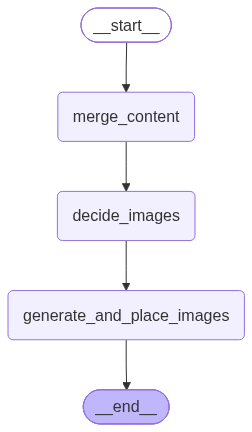

In [10]:
# build reducer subgraph
reducer_graph = StateGraph(State)
reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)
reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)
reducer_subgraph = reducer_graph.compile()

reducer_subgraph

In [ ]:
def reducer_node(state: State) -> dict:
    """Run the reducer subgraph but only return the keys it produces.
    Adding the compiled subgraph directly as a node would hand its whole
    state back to the parent, and the `sections` operator.add reducer
    would append every section a second time."""
    out = reducer_subgraph.invoke(state)
    return {k: out[k] for k in ("merged_md", "md_with_placeholders", "image_specs", "final")}


# -----------------------------
# 9) Build main graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app


In [12]:
# -----------------------------
# 10) Runner
# -----------------------------
def run(topic: str, as_of: Optional[str] = None):
    if as_of is None:
        as_of = date.today().isoformat()

    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "as_of": as_of,
            "recency_days": 7,
            "sections": [],
            "merged_md": "",
            "md_with_placeholders": "",
            "image_specs": [],
            "final": "",
        }
    )

    plan = out["plan"]
    print(f"mode={out['mode']}  evidence={len(out['evidence'])}  sections={len(out['sections'])}")
    print(f"title: {plan.blog_title}")
    print(f"saved: {slugify(plan.blog_title)}.md  ({len(out['final'])} chars)")
    for spec in out["image_specs"]:
        print(f"image: {spec['placeholder']} -> images/{slugify(Path(spec['filename']).stem)}.png")
    if "[IMAGE GENERATION FAILED]" in out["final"]:
        print("WARNING: at least one image failed to generate — see the fallback block in the markdown.")
    return out

In [28]:
run("Self Attention in Transformer Architecture")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


mode=closed_book  evidence=0  sections=14
title: Self-Attention in Transformer Architecture: A Deep Dive
saved: self_attention_in_transformer_architecture_a_deep_dive.md  (22754 chars)
image: [[IMAGE_1]] -> images/qkv_multihead_flow.png
image: [[IMAGE_2]] -> images/flash_attention_tiling.png
image: [[IMAGE_3]] -> images/sparse_attention_patterns.png


{'topic': 'Self Attention in Transformer Architecture',
 'mode': 'closed_book',
 'needs_research': False,
 'queries': [],
 'evidence': [],
 'plan': Plan(blog_title='Self-Attention in Transformer Architecture: A Deep Dive', audience='ML engineers and developers building or debugging transformer models', tone='technical and precise with practical insights', blog_kind='explainer', constraints=['closed_book mode - evergreen content only', 'include at least one minimal code sketch', 'cover edge cases/failure modes', 'address performance considerations'], tasks=[Task(id=1, title='Why Self-Attention? Motivation and Core Intuition', goal='Understand the problem self-attention solves and why it replaced recurrence and convolution for sequence modeling.', bullets=['Contrast self-attention with RNNs and CNNs on parallelization, long-range dependencies, and inductive bias', 'Explain the key-value-query analogy using retrieval as a mental model', 'Describe how attention weights form a dynamic, cont

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


mode=closed_book  evidence=0  sections=16
title: Self-Attention in Transformer Architecture: A Deep Dive
saved: self_attention_in_transformer_architecture_a_deep_dive.md  (26032 chars)
image: [[IMAGE_1]] -> images/scaled_dot_product_attention.png
image: [[IMAGE_2]] -> images/multi_head_attention_flow.png
image: [[IMAGE_3]] -> images/positional_encoding_comparison.png


{'topic': 'Self Attention in Transformer Architecture',
 'mode': 'closed_book',
 'needs_research': False,
 'queries': [],
 'evidence': [],
 'plan': Plan(blog_title='Self-Attention in Transformer Architecture: A Deep Dive', audience='Software engineers and ML practitioners familiar with neural networks but seeking deeper understanding of attention mechanisms', tone='Technical, precise, and implementation-oriented', blog_kind='explainer', constraints=['Closed-book mode: evergreen content only, no version-specific claims', 'Include at least one minimal working code example', 'Cover edge cases, performance implications, and debugging strategies'], tasks=[Task(id=1, title='Why Self-Attention Replaced Recurrence', goal='Explain the motivation behind self-attention and how it overcomes the sequential bottleneck of RNNs/LSTMs.', bullets=['Contrast sequential processing in RNNs with parallelizable attention computation', 'Describe the vanishing gradient problem in long sequences and how attenti